<a href="https://colab.research.google.com/github/sangrammagar/My_projects/blob/main/Neural_Style_Transfer_(NST)_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iteration 0, Loss: 8675138560.00
Iteration 20, Loss: 502663552.00
Iteration 40, Loss: 190213136.00
Iteration 60, Loss: 115397216.00
Iteration 80, Loss: 86871944.00


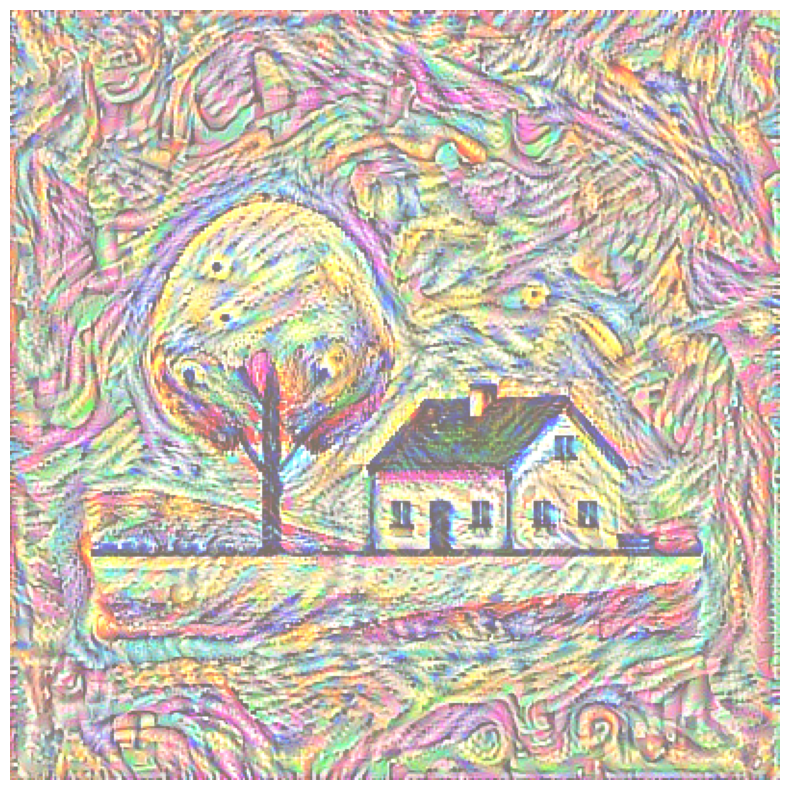

In [23]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg19 import VGG19, preprocess_input
from tensorflow.keras.models import Model

# Simplified functions
def load_image(path, max_size=400):
    img = load_img(path, target_size=(max_size, max_size))
    img = img_to_array(img)
    img = preprocess_input(img)
    return tf.expand_dims(img, axis=0)

def deprocess_image(img):
    img = img.numpy().squeeze()
    img[:, :, 0] += 103.939
    img[:, :, 1] += 116.779
    img[:, :, 2] += 123.68
    img = img[:, :, ::-1]  # BGR to RGB
    return np.clip(img, 0, 255).astype('uint8')

# Get model with intermediate layers
def get_model():
    vgg = VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False
    # Use these layers for style and content
    style_layers = ['block1_conv1', 'block2_conv1', 'block3_conv1', 'block4_conv1', 'block5_conv1']
    content_layer = 'block5_conv2'
    outputs = [vgg.get_layer(name).output for name in (style_layers + [content_layer])]
    return Model(vgg.input, outputs)

# Corrected Gram matrix calculation
def gram_matrix(input_tensor):
    # Input tensor is (1, height, width, channels)
    channels = int(input_tensor.shape[-1])
    a = tf.reshape(input_tensor, [-1, channels])  # Flatten to (height*width, channels)
    gram = tf.matmul(a, a, transpose_a=True)  # (channels, channels)
    return gram / tf.cast(tf.shape(a)[0], tf.float32)

# Loss functions
def content_loss(content, target):
    return tf.reduce_mean(tf.square(content - target))

def style_loss(style, gram_target):
    gram_style = gram_matrix(style)
    return tf.reduce_mean(tf.square(gram_style - gram_target))

# Main style transfer function
def style_transfer(content_path, style_path, iterations=1000, content_weight=1e4, style_weight=1e-2):
    # Load images
    content = load_image(content_path)
    style = load_image(style_path)

    # Initialize generated image (start with content image)
    generated = tf.Variable(content, dtype=tf.float32)

    # Get model
    model = get_model()

    # Get style and content targets
    style_outputs = model(style)
    content_output = model(content)[-1]  # Last output is content

    # Style targets (gram matrices)
    style_targets = [gram_matrix(style_layer) for style_layer in style_outputs[:-1]]

    # Optimizer
    opt = tf.optimizers.Adam(learning_rate=5.0)

    for i in range(iterations):
        with tf.GradientTape() as tape:
            outputs = model(generated)

            # Content loss (last output)
            c_loss = content_loss(outputs[-1], content_output)

            # Style loss (all outputs except last)
            s_loss = tf.add_n([style_loss(style_output, target)
                             for style_output, target in zip(outputs[:-1], style_targets)])

            # Total loss
            total_loss = content_weight * c_loss + style_weight * s_loss

        # Apply gradients
        grad = tape.gradient(total_loss, generated)
        opt.apply_gradients([(grad, generated)])
        generated.assign(tf.clip_by_value(generated, 0.0, 255.0))

        if i % 20 == 0:
            print(f"Iteration {i}, Loss: {total_loss:.2f}")

    return deprocess_image(generated)

# Run with example images
content_path = "/content/Screenshot 2025-03-26 141138.png"
style_path = "/content/Screenshot 2025-03-26 141148.png"
result = style_transfer(content_path, style_path, iterations=100)

# Show result
plt.figure(figsize=(10, 10))
plt.imshow(result)
plt.axis('off')
plt.show()

In [ ]:
from PIL import Image
Image.fromarray(result).save("stylized_output.png")
